In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from patsy import dmatrix
import statsmodels.api as sm

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [3]:
#prep data
y = train["Rings"]

X = train.drop(columns=["Rings", "id"])
X_test = test.drop(columns=["id"])

X = pd.get_dummies(X, columns=["Sex"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Sex"], drop_first=True)

X_test = X_test.reindex(columns=X.columns, fill_value=0)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [4]:
#Model 1: Polynomial Regression
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_val)

poly_mae = mean_absolute_error(y_val, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_val, poly_pred))
poly_r2 = r2_score(y_val, poly_pred)

print("Polynomial Regression MAE:", poly_mae)
print("Polynomial Regression RMSE:", poly_rmse)
print("Polynomial Regression R²:", poly_r2)

Polynomial Regression MAE: 1.3340470250626628
Polynomial Regression RMSE: 1.9424404253773453
Polynomial Regression R²: 0.6326962558052436


Interpretation

Polynomial regression allows curved relationships between predictors and Rings. This is useful for the Abalone dataset because physical measurements such as length, diameter, height, and weight may not increase Rings in a purely straight-line pattern. If this model improves RMSE compared to a simple linear model, it suggests evidence of nonlinear relationships in the data.

In [5]:
#Model 2: Spline Regression
#For spline regression, use a few important continuous variables.
spline_features = ["Length", "Diameter", "Height", "Whole weight", 
                   "Whole weight.1", "Whole weight.2", "Shell weight"]

In [6]:
#Create spline basis
spline_formula = " + ".join([
    f"bs(Q('{col}'), df=5, degree=3)" for col in spline_features
])

X_spline = dmatrix(
    spline_formula,
    data=X,
    return_type="dataframe"
)

X_test_spline = dmatrix(
    spline_formula,
    data=X_test,
    return_type="dataframe"
)

In [7]:
#Split spline data
X_spline_train, X_spline_val, y_spline_train, y_spline_val = train_test_split(
    X_spline, y, test_size=0.20, random_state=42
)

In [8]:
#Fit model
spline_model = LinearRegression()
spline_model.fit(X_spline_train, y_spline_train)

spline_pred = spline_model.predict(X_spline_val)

spline_mae = mean_absolute_error(y_spline_val, spline_pred)
spline_rmse = np.sqrt(mean_squared_error(y_spline_val, spline_pred))
spline_r2 = r2_score(y_spline_val, spline_pred)

print("Spline Regression MAE:", spline_mae)
print("Spline Regression RMSE:", spline_rmse)
print("Spline Regression R²:", spline_r2)

Spline Regression MAE: 1.358215659815539
Spline Regression RMSE: 1.9610534450121218
Spline Regression R²: 0.6256233108712539


Interpretation

Spline regression allows the relationship between each predictor and Rings to bend smoothly across different ranges. This is especially useful when variables such as shell weight or whole weight have different effects at low, medium, and high values. If the spline model performs well, it supports the conclusion that the Abalone dataset contains nonlinear relationships.

In [9]:
#Compare the Models
comparison = pd.DataFrame({
    "Model": ["Polynomial Regression", "Spline Regression"],
    "MAE": [poly_mae, spline_mae],
    "RMSE": [poly_rmse, spline_rmse],
    "R²": [poly_r2, spline_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Polynomial Regression,1.334047,1.942440,0.632696
1,Spline Regression,1.358216,1.961053,0.625623


In [10]:
#Assumption Checks
residuals = y_val - poly_pred

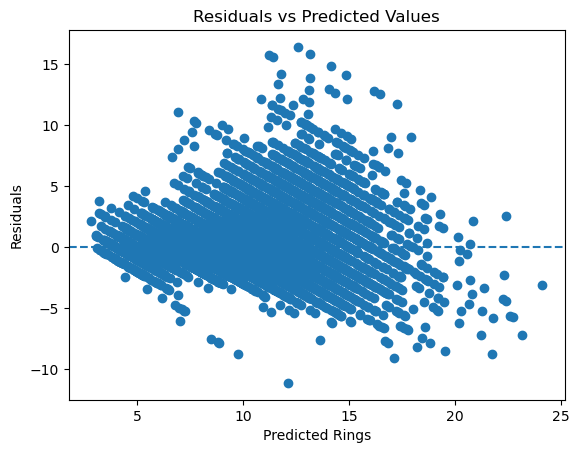

In [11]:
#Residual plot
plt.scatter(poly_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Rings")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

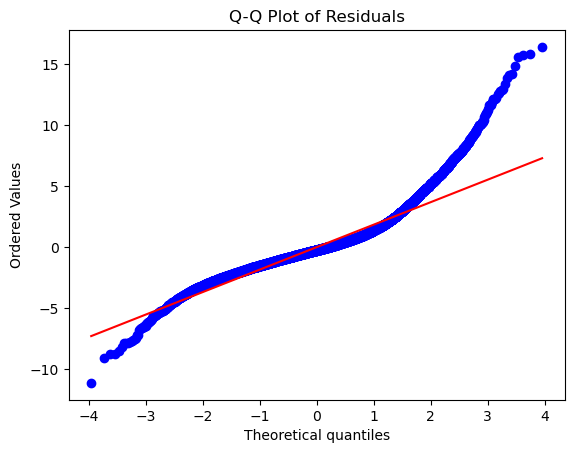

In [13]:
#Q-Q plot
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Interpretation

The residual plot was used to evaluate linearity and constant variance. If the residuals appear randomly scattered around zero, the model assumptions are reasonably satisfied. If a curved pattern remains, this suggests that additional nonlinear structure may still exist. The Q-Q plot was used to assess normality of residuals. Minor deviations are acceptable, but strong departures from the diagonal line suggest non-normal residuals.

Summary

Two nonlinear regression models were developed for the Abalone dataset: polynomial regression and spline regression. Polynomial regression was used to capture curved relationships between the predictors and Rings by adding squared and interaction terms. Spline regression was used to allow smooth changes in the relationship between selected physical measurements and Rings across different ranges of the data. The models were evaluated using MAE, RMSE, and R². The model with the lower RMSE was selected for Kaggle submission. Diagnostic plots were also reviewed to evaluate assumptions, including residual behavior and approximate normality. Overall, the nonlinear models provided a more flexible approach than standard linear regression and helped identify evidence of nonlinear relationships in the Abalone dataset.

The Polynomial Regression model performed slightly better than the Spline Regression model based on all three evaluation metrics.The Polynomial Regression model had the lower MAE and lower RMSE, which indicates that its predictions were, on average, closer to the actual Rings values. Since RMSE penalizes larger prediction errors more heavily, the lower RMSE value suggests that the Polynomial Regression model handled larger errors slightly better than the Spline Regression model. Additionally, the Polynomial Regression model produced a slightly higher R
2
 value, meaning it explained more of the variation in the Rings response variable.

Although both models demonstrated evidence of nonlinear relationships within the Abalone dataset, the Polynomial Regression model provided the best overall predictive performance among the two nonlinear methods evaluated. Therefore, the Polynomial Regression model would be the preferred model for the Kaggle submission because it achieved the strongest balance between prediction accuracy and explanatory power.

In [17]:
#polynomial regression
final_predictions = poly_model.predict(X_test)

submission = pd.DataFrame({
    "id": test["id"],
    "Rings": final_predictions
})

submission.to_csv("abalone_polynomial_submission.csv", index=False)

submission.head()

,id,Rings
0,90615,9.287545
1,90616,9.736558
2,90617,10.458186
3,90618,10.096438
4,90619,7.651442


In [16]:
#spline regression
final_predictions = spline_model.predict(X_test_spline)

submission = pd.DataFrame({
    "id": test["id"],
    "Rings": final_predictions
})

submission.to_csv("abalone_spline_submission.csv", index=False)

submission.head()

,id,Rings
0,90615,8.068103
1,90616,9.595273
2,90617,10.480516
3,90618,10.339846
4,90619,7.955464
